In [1]:
%matplotlib inline

import sys

sys.path.append('../../../../')

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

In [2]:
from __future__ import annotations
from typing import Optional, Union, Sequence, Callable

import os
from functools import partial

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.modules.utils import _pair

import numpy as np

from mmengine import Config, DictAction

%load_ext autoreload
%autoreload 2

from computer_vision.slowfast.mmaction.datasets.transforms.loading import DecordInit, SampleFrames, DecordDecode
from computer_vision.slowfast.mmaction.datasets.transforms.processing import Resize, _init_lazy_of_proper, RandomCrop, CenterCrop, ThreeCrop, \
RandomResizedCrop, Flip
from computer_vision.slowfast.mmaction.datasets.transforms.formatting import FormatShape, PackActionInputs

from computer_vision.slowfast.mmengine.dataset.utils import pseudo_collate, worker_init_fn
from computer_vision.slowfast.parameter_parser import parser, merge_args
from computer_vision.slowfast.mmaction.datasets.video_dataset import VideoDataset
from computer_vision.slowfast.mmengine.dataset.sampler import DefaultSampler

In [3]:
config="../../config/slowfast_r50_8xb8-4x16x1-256e_kinetics400-rgb.py"

data_dirpath='D:/data/UCF101'
# root=f'{data_dirpath}/UCF-101'
annotation_path='UCF101TrainTestSplits-RecognitionTask/trainlist02.txt'
metadata_path=f'{data_dirpath}/metadata.pt'

mini_train=False
if not mini_train:
    output_dirpath="D:/results/ucf101/mmaction2-slowfast/train"
    arguments= f"""-d {data_dirpath} -a {annotation_path} 
    """ # --use-cutmix-mixup
else:
    output_dirpath="D:/results/ucf101/mmaction2-slowfast/mini_train"
    arguments= f"""-d {data_dirpath} -a {annotation_path}
    """ # --use-cutmix-mixup --time 18
    
arguments+=f"""--data-prefix UCF-101 {config} --work-dir {output_dirpath} --auto-scale-lr --seed 1"""


args=parser.parse_args(arguments.split())
cfg=Config.fromfile(args.config)
args=merge_args(cfg, args)


len(dataset)=3196
data_info={'filename': 'D:/data/UCF101\\UCF-101\\BaseballPitch/v_BaseballPitch_g03_c07.avi', 'label': 7, 'sample_idx': 199, 'modality': 'RGB', 'start_index': 0}
dict_keys(['inputs', 'data_samples']), <ActionDataSample(

    META INFORMATION
    img_shape:(224, 224)

    DATA FIELDS
    gt_label:tensor([7])
) at 0x23184814fd0>, data['inputs'].shape=torch.Size([1, 3, 32, 224, 224])
data['inputs'].shape=torch.Size([1, 3, 32, 224, 224]), torch.uint8
sampled_imgs.shape=torch.Size([4, 3, 224, 224])


(-0.5, 905.5, 227.5, -0.5)

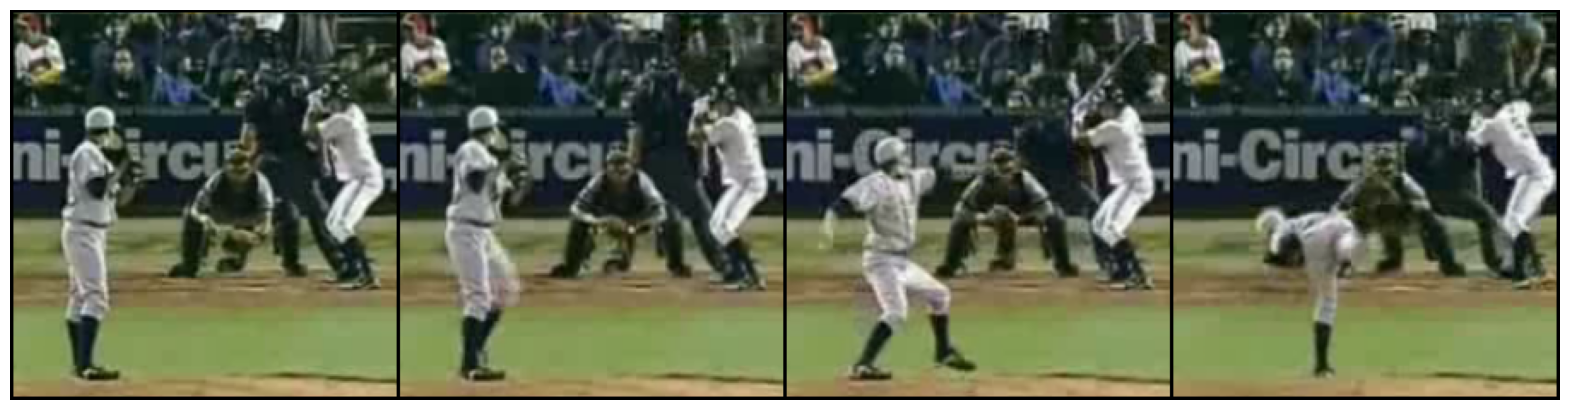

In [6]:
pipeline=[DecordInit(io_backend='disk'),
            SampleFrames(clip_len=32, frame_interval=2, num_clips=1, test_mode=True),
            DecordDecode(),
            Resize(scale=(-1, 256), keep_ratio=True, interpolation='bilinear', lazy=False),
            CenterCrop(crop_size=224),
            FormatShape(input_format='NCTHW'),
            PackActionInputs()]
# we note here multi_class is just to inform the class to compute onehot
dataset=VideoDataset(ann_file=args.ann_file, pipeline=pipeline, data_root=args.data_root, data_prefix=dict(video=args.data_prefix), test_mode=True,
                     multi_class=False, num_classes=None, start_index=0, modality='RGB', delimiter=' ', lazy_init=False, 
                    indices=np.arange(0, 9586,3).tolist()) # 9586 is the original number of data
print(f"{len(dataset)=}")
# `__getitem__` call `prepare_data` which calls  `data_info=self.get_data_info(idx)` and `data=self.pipeline(data_info)`
idx=199
data_info=dataset.get_data_info(idx)
print(f"{data_info=}")
data=dataset.pipeline(data_info)
print(f"{data.keys()}, {data['data_samples']}, {data['inputs'].shape=}")

n_clips,C,T,H,W=data['inputs'].shape
print(f"{data['inputs'].shape=}, {data['inputs'].dtype}")
# from (n_clips,C,T,H,W) to (n_clips,T,C,H,W) to (n_clips*T,C,H,W)
sampled_imgs=data['inputs'].permute(0,2,1,3,4).reshape(-1,C,H,W)[::10]  
print(f"{sampled_imgs.shape=}")

_, ax=plt.subplots(figsize=(20,20))
ax.imshow(make_grid(sampled_imgs, nrow=8).permute(1,2,0))
ax.axis("off")

In [7]:
seed=1
sampler=DefaultSampler(dataset, shuffle=False, seed=seed, round_up=True)
init_fn=partial(worker_init_fn, num_workers=8, rank=0, seed=seed)
dataloader=DataLoader(dataset=dataset, batch_size=8, sampler=sampler, num_workers=8, persistent_workers=True,
                  collate_fn=pseudo_collate, worker_init_fn=init_fn)
print(f"{len(dataloader)=}")
data=next(iter(dataloader))
print(f"{type(data)=}, {len(data)=}, {data.keys()=}, {[x.shape for x in data['inputs']]=}, {data['data_samples']=}")


len(dataloader)=400
type(data)=<class 'dict'>, len(data)=2, data.keys()=dict_keys(['inputs', 'data_samples']), [x.shape for x in data['inputs']]=[torch.Size([1, 3, 32, 224, 224]), torch.Size([1, 3, 32, 224, 224]), torch.Size([1, 3, 32, 224, 224]), torch.Size([1, 3, 32, 224, 224]), torch.Size([1, 3, 32, 224, 224]), torch.Size([1, 3, 32, 224, 224]), torch.Size([1, 3, 32, 224, 224]), torch.Size([1, 3, 32, 224, 224])], data['data_samples']=[<ActionDataSample(

    META INFORMATION
    img_shape:(224, 224)

    DATA FIELDS
    gt_label:tensor([1])
) at 0x2318580f220>, <ActionDataSample(

    META INFORMATION
    img_shape:(224, 224)

    DATA FIELDS
    gt_label:tensor([1])
) at 0x2318580f460>, <ActionDataSample(

    META INFORMATION
    img_shape:(224, 224)

    DATA FIELDS
    gt_label:tensor([1])
) at 0x2318580f6a0>, <ActionDataSample(

    META INFORMATION
    img_shape:(224, 224)

    DATA FIELDS
    gt_label:tensor([1])
) at 0x2318580f880>, <ActionDataSample(

    META INFORMATION
  

In [8]:
class_id_fpath=f'{data_dirpath}/UCF101TrainTestSplits-RecognitionTask/classInd.txt'
with open(class_id_fpath, 'r', encoding='utf-8') as f: class_ids=f.read().strip().split('\n')
class_ids=dict([int(x) if i==0 else x for i, x in enumerate(term.split(' '))] for term in class_ids)

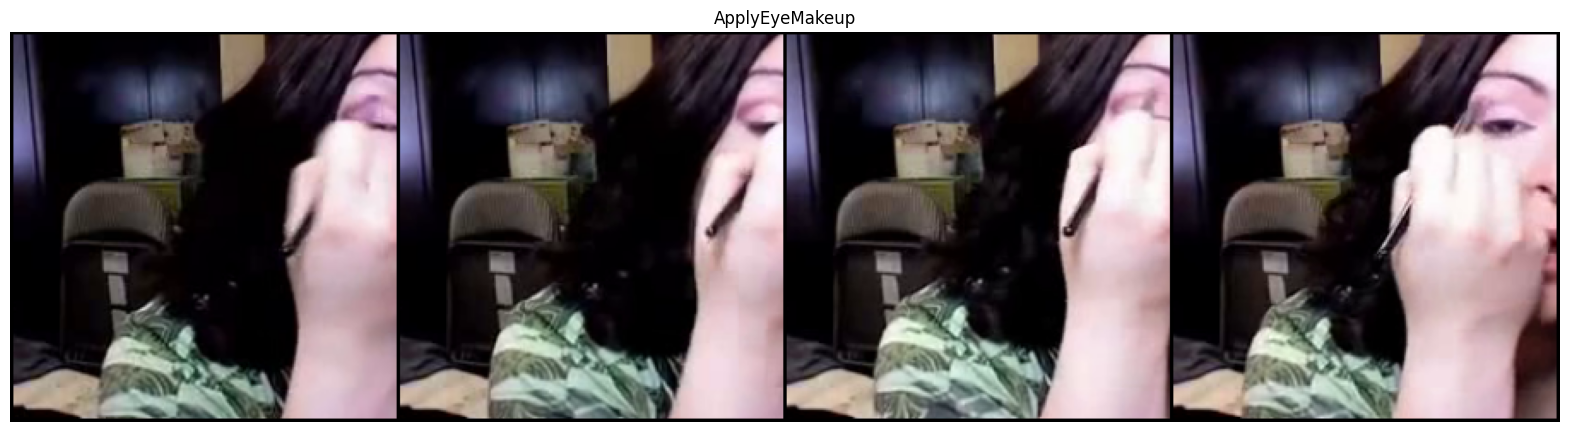

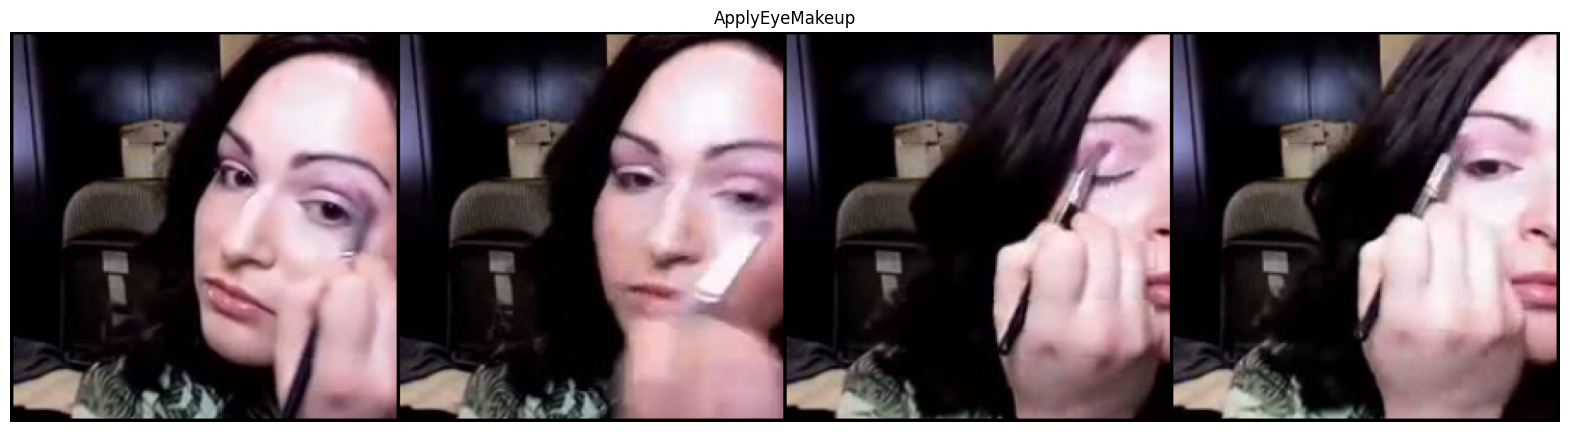

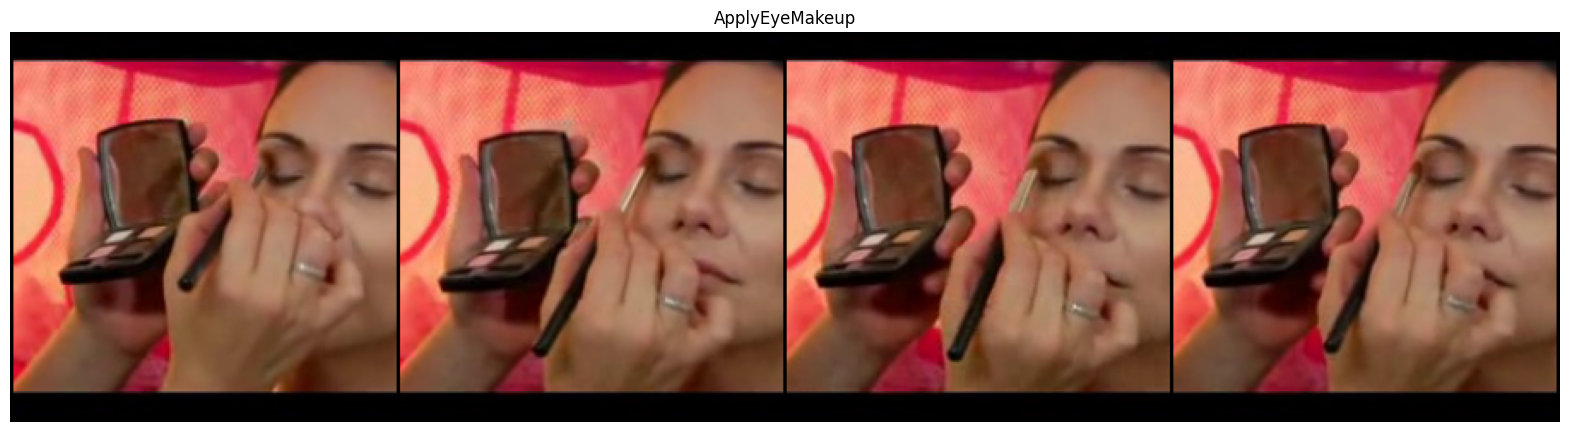

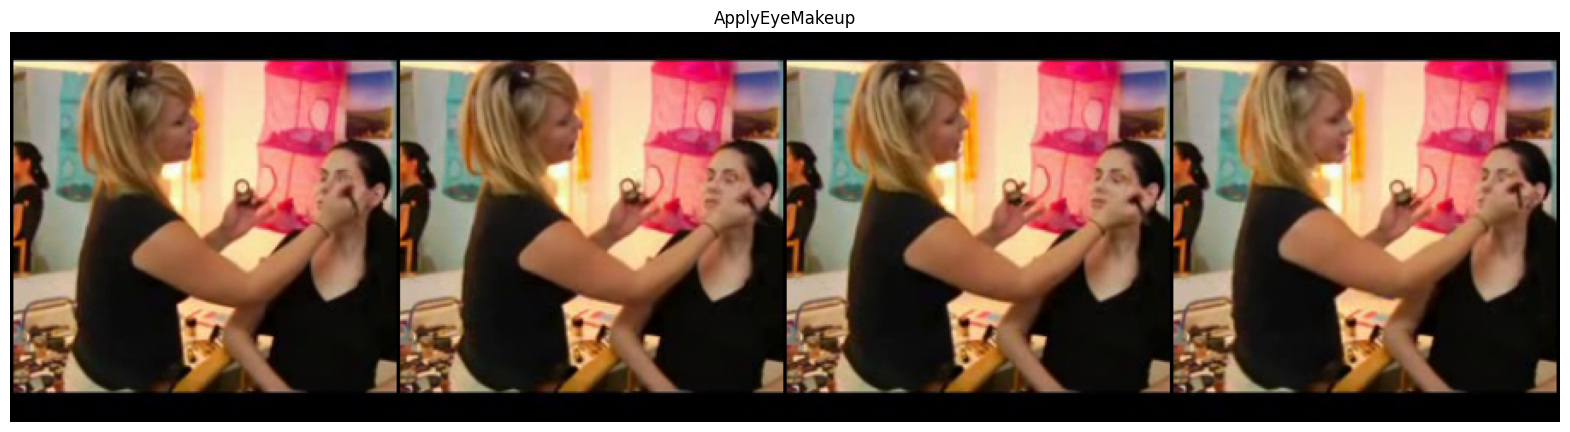

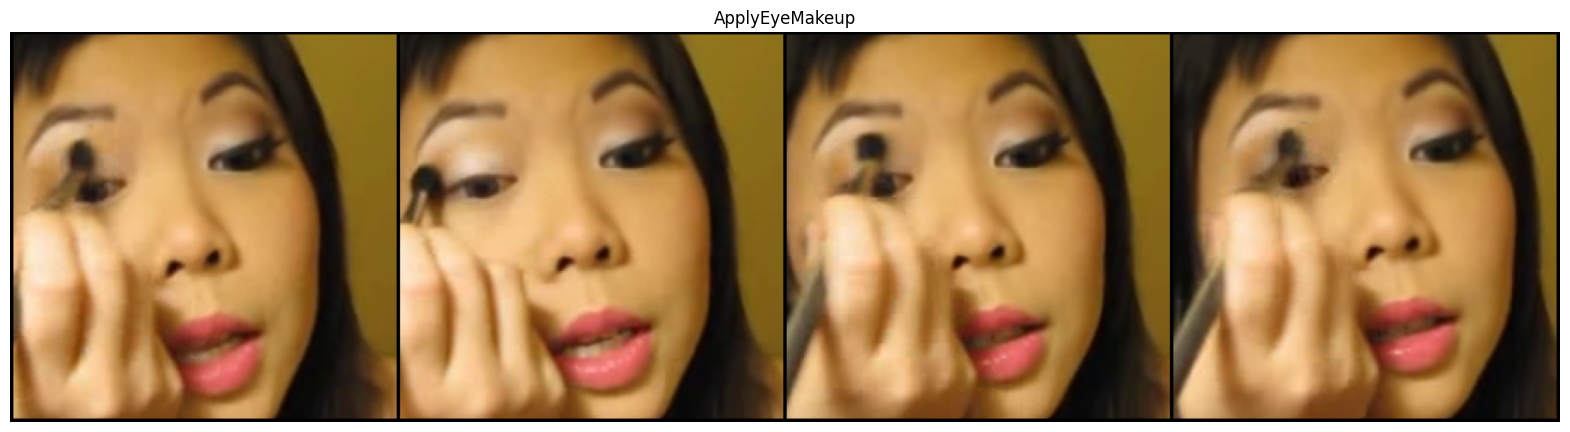

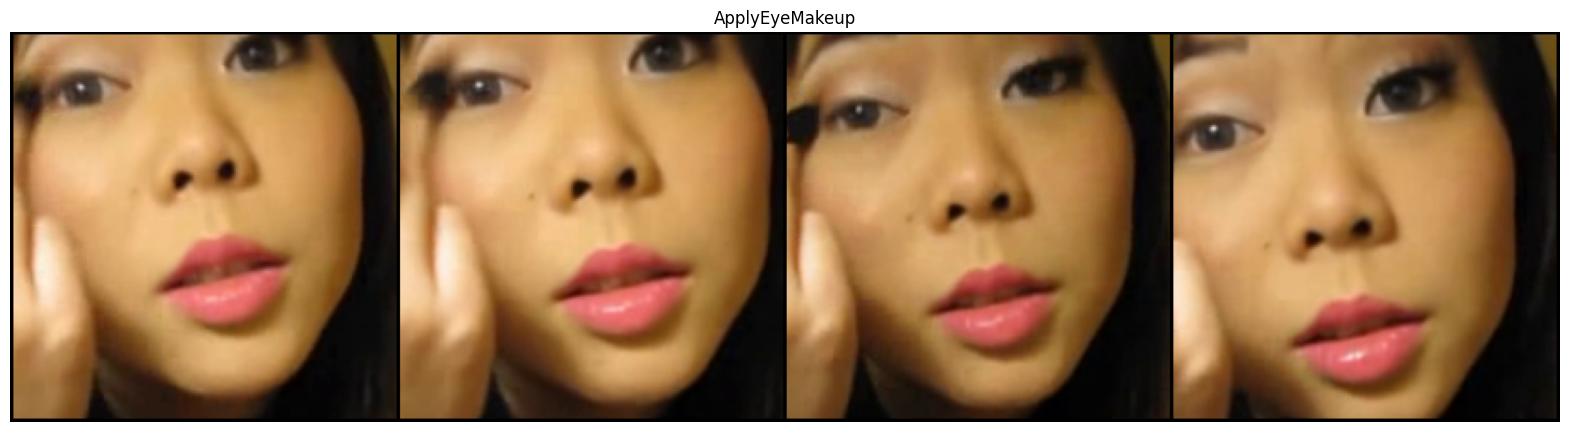

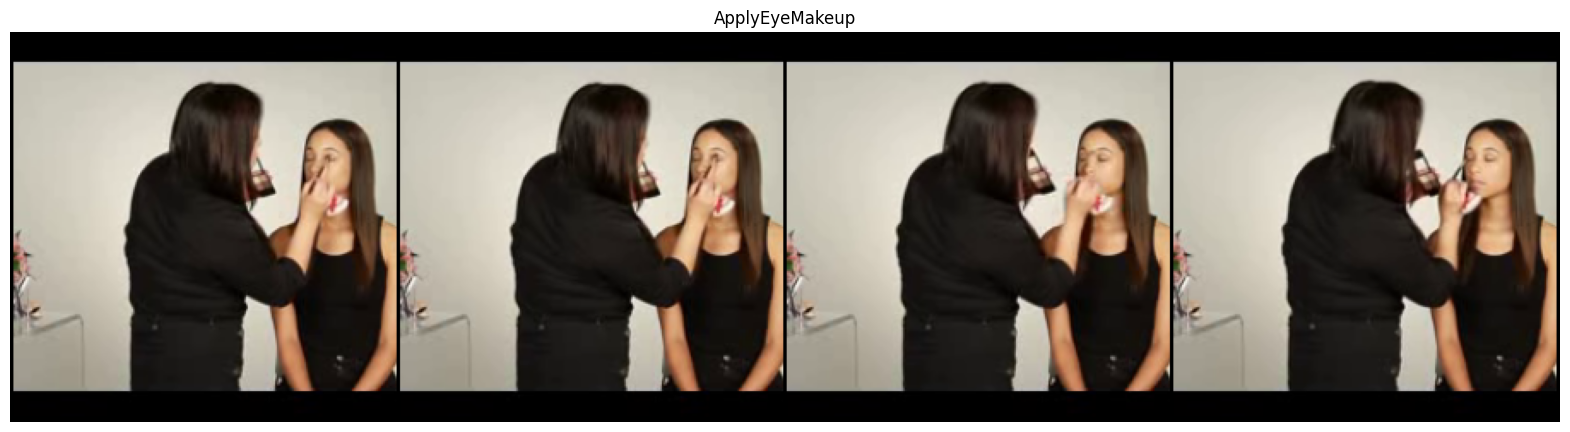

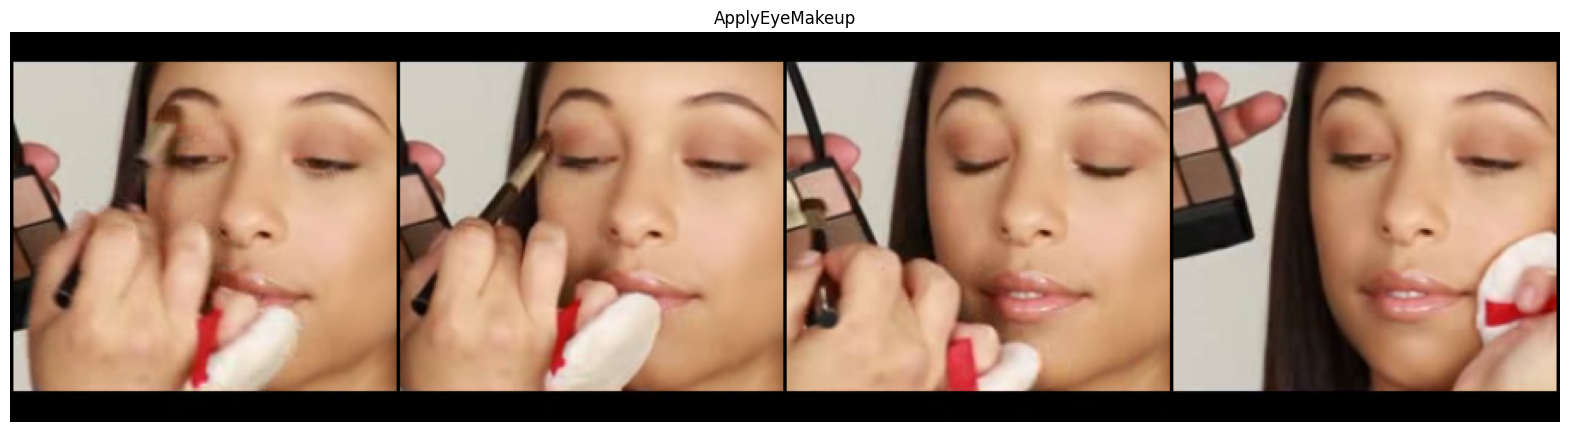

In [9]:
for i, vid in enumerate(data['inputs']):

    n_clips,C,T,H,W=vid.shape
    # from (n_clips,C,T,H,W) to (n_clips,T,C,H,W) to (n_clips*T,C,H,W)
    sampled_imgs=vid.permute(0,2,1,3,4).reshape(-1,C,H,W)[::10]  

    label=data['data_samples'][i].get('gt_label').item()
    txt=class_ids[label] if label in class_ids else 'NA'

    _, ax=plt.subplots(figsize=(20,20))
    ax.imshow(make_grid(sampled_imgs, nrow=8).permute(1,2,0))
    ax.set_title(txt)
    ax.axis("off")
